# MIMIC Fidelity Analysis: Real-Data Validation of the Positive-Count Hypothesis

In [1]:
library(duckdb)
library(DBI)
library(dplyr)
library(synthpop)
library(ggplot2)
library(tidyr)

source("config.R")

Loading required package: DBI


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


New version of synthpop (1.9-0) with disclosure functions
see disclosure.pdf for details and NEWS file for other changes

Find out more at https://www.synthpop.org.uk/



In [2]:
con <- dbConnect(duckdb())

dbExecute(con, sprintf(
  "CREATE VIEW diagnoses_icd AS SELECT * FROM read_csv_auto('%s/hosp/diagnoses_icd.csv.gz')",
  DATA_DIR))
dbExecute(con, sprintf(
  "CREATE VIEW d_icd_diagnoses AS SELECT * FROM read_csv_auto('%s/hosp/d_icd_diagnoses.csv.gz')",
  DATA_DIR))
dbExecute(con, sprintf(
  "CREATE VIEW icustays AS SELECT * FROM read_csv_auto('%s/icu/icustays.csv.gz')",
  DATA_DIR))
dbExecute(con, sprintf(
  "CREATE VIEW patients AS SELECT * FROM read_csv_auto('%s/hosp/patients.csv.gz')",
  DATA_DIR))
dbExecute(con, sprintf(
  "CREATE VIEW admissions AS SELECT * FROM read_csv_auto('%s/hosp/admissions.csv.gz')",
  DATA_DIR))
dbExecute(con, sprintf(
  "CREATE VIEW labevents AS SELECT * FROM read_csv_auto('%s/hosp/labevents.csv.gz')",
  DATA_DIR))
dbExecute(con, sprintf(
  "CREATE VIEW d_labitems AS SELECT * FROM read_csv_auto('%s/hosp/d_labitems.csv.gz')",
  DATA_DIR))

duckdb keeps downloaded extensions and secrets in a temporary directory:
ℹ /var/folders/5d/pvxmh0mx4f124ss1c7t2ymk00000gn/T//RtmpJoCKB5/duckdb
This is removed when the R session ends.
• Extensions are re-downloaded each session.
• Secrets are lost.
ℹ Run duckdb(shared_home = TRUE) (or create ~/.duckdb) to keep them (suitable for most users).
ℹ Run duckdb(shared_home = FALSE) to accept the temporary directory (and silence this message).
ℹ See ?duckdb_storage for details and alternatives.


[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

## Comorbidity Screening: Positive Count by Category

In [3]:
comorbidity_counts <- dbGetQuery(con, "
  SELECT
    CASE
      WHEN icd_version = 9  AND icd_code LIKE '428%' THEN 'CHF'
      WHEN icd_version = 10 AND icd_code LIKE 'I50%'  THEN 'CHF'
      WHEN icd_version = 9  AND icd_code LIKE '250%' THEN 'Diabetes'
      WHEN icd_version = 10 AND (icd_code LIKE 'E10%' OR icd_code LIKE 'E11%'
                               OR icd_code LIKE 'E12%' OR icd_code LIKE 'E13%'
                               OR icd_code LIKE 'E14%') THEN 'Diabetes'
      WHEN icd_version = 9  AND icd_code IN ('491','492','494','496') THEN 'COPD'
      WHEN icd_version = 10 AND icd_code LIKE 'J44%' THEN 'COPD'
      WHEN icd_version = 9  AND icd_code LIKE '584%' THEN 'Renal Failure'
      WHEN icd_version = 9  AND icd_code LIKE '585%' THEN 'Renal Failure'
      WHEN icd_version = 9  AND icd_code LIKE '586%' THEN 'Renal Failure'
      WHEN icd_version = 10 AND (icd_code LIKE 'N17%' OR icd_code LIKE 'N18%'
                               OR icd_code LIKE 'N19%') THEN 'Renal Failure'
      WHEN icd_version = 9  AND icd_code LIKE '401%' THEN 'Hypertension'
      WHEN icd_version = 10 AND (icd_code LIKE 'I10%' OR icd_code LIKE 'I11%'
                               OR icd_code LIKE 'I12%' OR icd_code LIKE 'I13%'
                               OR icd_code LIKE 'I15%') THEN 'Hypertension'
      ELSE NULL
    END AS comorbidity,
    COUNT(DISTINCT d.hadm_id) AS positive_count
  FROM diagnoses_icd d
  WHERE d.hadm_id IN (SELECT DISTINCT hadm_id FROM icustays)
    AND comorbidity IS NOT NULL
  GROUP BY comorbidity
  ORDER BY positive_count
")
print(comorbidity_counts)

    comorbidity positive_count
1          COPD           7244
2           CHF          17412
3      Diabetes          19806
4 Renal Failure          25369
5  Hypertension          34979


## Continuous Variable Selection

In [4]:
creatinine_items <- dbGetQuery(con, "
  SELECT itemid, label, fluid, category
  FROM d_labitems
  WHERE LOWER(label) LIKE '%creatinine%'
    AND fluid = 'Blood'
  ORDER BY label
")
print(creatinine_items)

  itemid                   label fluid  category
1  50912              Creatinine Blood Chemistry
2  52546              Creatinine Blood Chemistry
3  52024 Creatinine, Whole Blood Blood Blood Gas


In [5]:
creatinine_coverage <- dbGetQuery(con, "
  WITH total AS (
    SELECT COUNT(*) AS n_stays FROM icustays
  ),
  with_creatinine AS (
    SELECT COUNT(DISTINCT i.stay_id) AS n_with_creatinine
    FROM icustays i
    JOIN labevents l ON i.hadm_id = l.hadm_id
    WHERE l.itemid IN (50912, 52546, 52024)
      AND l.charttime BETWEEN i.intime AND i.intime + INTERVAL 24 HOUR
      AND l.valuenum IS NOT NULL
  )
  SELECT
    total.n_stays,
    with_creatinine.n_with_creatinine,
    ROUND(100.0 * with_creatinine.n_with_creatinine / total.n_stays, 1) AS coverage_pct
  FROM total, with_creatinine
")
print(creatinine_coverage)

  n_stays n_with_creatinine coverage_pct
1   73181             70954           97


In [6]:
creatinine_firstday <- dbGetQuery(con, "
  SELECT
    i.stay_id,
    MAX(l.valuenum) AS creatinine_max
  FROM icustays i
  JOIN labevents l ON i.hadm_id = l.hadm_id
  WHERE l.itemid IN (50912, 52546, 52024)
    AND l.charttime BETWEEN i.intime AND i.intime + INTERVAL 24 HOUR
    AND l.valuenum IS NOT NULL
  GROUP BY i.stay_id
")
str(creatinine_firstday)
summary(creatinine_firstday$creatinine_max)

'data.frame':	70954 obs. of  2 variables:
 $ stay_id       : num  38728878 36015412 35166659 36989776 32233246 ...
 $ creatinine_max: num  1.3 1.4 0.7 5.5 1.8 7.3 0.7 1.2 3 0.6 ...


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.700   1.000   1.509   1.500  80.000 

In [7]:
CAP <- quantile(creatinine_firstday$creatinine_max, 0.995, na.rm = TRUE)
creatinine_firstday$creatinine_max_capped <- pmin(creatinine_firstday$creatinine_max, CAP)
print(CAP)

99.5% 
   11 


## Build Flat Table

In [8]:
cohort_base <- dbGetQuery(con, "
  SELECT
    i.stay_id, i.hadm_id, i.subject_id, i.intime, i.outtime, i.los,
    p.gender, p.anchor_age,
    a.admission_type, a.insurance, a.hospital_expire_flag,
    MAX(CASE WHEN (d.icd_version = 9  AND d.icd_code LIKE '428%')
             OR (d.icd_version = 10 AND d.icd_code LIKE 'I50%') THEN 1 ELSE 0 END) AS chf,
    MAX(CASE WHEN (d.icd_version = 9  AND d.icd_code LIKE '250%')
             OR (d.icd_version = 10 AND (d.icd_code LIKE 'E10%' OR d.icd_code LIKE 'E11%'
                                       OR d.icd_code LIKE 'E12%' OR d.icd_code LIKE 'E13%'
                                       OR d.icd_code LIKE 'E14%')) THEN 1 ELSE 0 END) AS diabetes,
    MAX(CASE WHEN (d.icd_version = 9  AND d.icd_code IN ('491','492','494','496'))
             OR (d.icd_version = 10 AND d.icd_code LIKE 'J44%') THEN 1 ELSE 0 END) AS copd,
    MAX(CASE WHEN (d.icd_version = 9  AND (d.icd_code LIKE '584%' OR d.icd_code LIKE '585%' OR d.icd_code LIKE '586%'))
             OR (d.icd_version = 10 AND (d.icd_code LIKE 'N17%' OR d.icd_code LIKE 'N18%'
                                       OR d.icd_code LIKE 'N19%')) THEN 1 ELSE 0 END) AS renal_failure,
    MAX(CASE WHEN (d.icd_version = 9  AND d.icd_code LIKE '401%')
             OR (d.icd_version = 10 AND (d.icd_code LIKE 'I10%' OR d.icd_code LIKE 'I11%'
                                       OR d.icd_code LIKE 'I12%' OR d.icd_code LIKE 'I13%'
                                       OR d.icd_code LIKE 'I15%')) THEN 1 ELSE 0 END) AS hypertension
  FROM icustays i
  LEFT JOIN patients p      ON i.subject_id = p.subject_id
  LEFT JOIN admissions a    ON i.hadm_id = a.hadm_id
  LEFT JOIN diagnoses_icd d ON i.hadm_id = d.hadm_id
  GROUP BY i.stay_id, i.hadm_id, i.subject_id, i.intime, i.outtime, i.los,
           p.gender, p.anchor_age, a.admission_type, a.insurance, a.hospital_expire_flag
")
str(cohort_base)

'data.frame':	73181 obs. of  16 variables:
 $ stay_id             : num  33032722 39256561 36933984 30813748 37420799 ...
 $ hadm_id             : num  27976104 26145445 23270127 22090317 26921214 ...
 $ subject_id          : num  10615674 10618339 10618469 10620832 10623984 ...
 $ intime              : POSIXct, format: "2119-07-26 17:57:00" "2165-10-03 09:57:47" ...
 $ outtime             : POSIXct, format: "2119-07-27 16:59:40" "2165-10-04 17:38:50" ...
 $ los                 : num  0.96 1.32 5.29 4.86 3.68 ...
 $ gender              : chr  "F" "M" "F" "M" ...
 $ anchor_age          : num  29 65 88 41 60 71 34 68 71 45 ...
 $ admission_type      : chr  "EW EMER." "URGENT" "SURGICAL SAME DAY ADMISSION" "EW EMER." ...
 $ insurance           : chr  "Medicaid" "Other" "Medicare" "Medicaid" ...
 $ hospital_expire_flag: num  0 0 0 0 0 0 0 0 0 1 ...
 $ chf                 : int  0 0 0 0 1 1 0 0 1 0 ...
 $ diabetes            : int  0 1 0 0 0 1 0 0 1 1 ...
 $ copd                : int  0 1 0

In [9]:
flat_table <- cohort_base %>%
  left_join(
    creatinine_firstday %>% select(stay_id, creatinine_max_capped),
    by = "stay_id"
  )

str(flat_table)

'data.frame':	73181 obs. of  17 variables:
 $ stay_id              : num  33032722 39256561 36933984 30813748 37420799 ...
 $ hadm_id              : num  27976104 26145445 23270127 22090317 26921214 ...
 $ subject_id           : num  10615674 10618339 10618469 10620832 10623984 ...
 $ intime               : POSIXct, format: "2119-07-26 17:57:00" "2165-10-03 09:57:47" ...
 $ outtime              : POSIXct, format: "2119-07-27 16:59:40" "2165-10-04 17:38:50" ...
 $ los                  : num  0.96 1.32 5.29 4.86 3.68 ...
 $ gender               : chr  "F" "M" "F" "M" ...
 $ anchor_age           : num  29 65 88 41 60 71 34 68 71 45 ...
 $ admission_type       : chr  "EW EMER." "URGENT" "SURGICAL SAME DAY ADMISSION" "EW EMER." ...
 $ insurance            : chr  "Medicaid" "Other" "Medicare" "Medicaid" ...
 $ hospital_expire_flag : num  0 0 0 0 0 0 0 0 0 1 ...
 $ chf                  : int  0 0 0 0 1 1 0 0 1 0 ...
 $ diabetes             : int  0 1 0 0 0 1 0 0 1 1 ...
 $ copd               

# Dataset Overview

In [10]:
preprocess <- function(df) {
  df$stay_id    <- NULL
  df$hadm_id    <- NULL
  df$subject_id <- NULL
  df$intime     <- NULL
  df$outtime    <- NULL

  df$gender               <- factor(df$gender)
  df$admission_type       <- factor(df$admission_type)
  df$insurance             <- factor(df$insurance)
  df$hospital_expire_flag <- factor(df$hospital_expire_flag, levels = c(0, 1))
  df$chf                  <- factor(df$chf,           levels = c(0, 1))
  df$diabetes             <- factor(df$diabetes,      levels = c(0, 1))
  df$copd                 <- factor(df$copd,          levels = c(0, 1))
  df$renal_failure        <- factor(df$renal_failure, levels = c(0, 1))
  df$hypertension         <- factor(df$hypertension,  levels = c(0, 1))

  return(df)
}

flat_table <- preprocess(flat_table)
str(flat_table)

'data.frame':	73181 obs. of  12 variables:
 $ los                  : num  0.96 1.32 5.29 4.86 3.68 ...
 $ gender               : Factor w/ 2 levels "F","M": 1 2 1 2 2 2 2 2 2 2 ...
 $ anchor_age           : num  29 65 88 41 60 71 34 68 71 45 ...
 $ admission_type       : Factor w/ 9 levels "AMBULATORY OBSERVATION",..: 6 9 8 6 9 6 6 8 6 7 ...
 $ insurance            : Factor w/ 3 levels "Medicaid","Medicare",..: 1 3 2 1 2 2 1 3 2 3 ...
 $ hospital_expire_flag : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 2 ...
 $ chf                  : Factor w/ 2 levels "0","1": 1 1 1 1 2 2 1 1 2 1 ...
 $ diabetes             : Factor w/ 2 levels "0","1": 1 2 1 1 1 2 1 1 2 2 ...
 $ copd                 : Factor w/ 2 levels "0","1": 1 2 1 1 1 1 1 1 1 1 ...
 $ renal_failure        : Factor w/ 2 levels "0","1": 1 1 2 1 1 2 1 1 2 2 ...
 $ hypertension         : Factor w/ 2 levels "0","1": 1 2 1 2 2 1 1 2 1 2 ...
 $ creatinine_max_capped: num  0.6 0.8 1.1 0.9 1.1 1.1 0.8 0.9 1.1 5.4 ...


# Estimation Functions

## get_interaction()

In [11]:
EXPLODE_THRESHOLD <- 2

get_interaction <- function(df, comorbidity_col) {
  formula_str <- paste0("hospital_expire_flag ~ anchor_age + creatinine_max_capped + ",
                         comorbidity_col, " + ", comorbidity_col, ":creatinine_max_capped")
  fit <- suppressWarnings(glm(as.formula(formula_str), data = df, family = binomial))
  coef(fit)[paste0("creatinine_max_capped:", comorbidity_col)]
}

## run_one_trial()

In [12]:
run_one_trial <- function(k, seed, n_fixed, pos_pool, neg_pool, comorbidity_col) {
  set.seed(seed)

  sub <- bind_rows(
    pos_pool[sample(nrow(pos_pool), k), ],
    neg_pool[sample(nrow(neg_pool), n_fixed - k), ]
  )

  syn_obj <- syn(sub, seed = seed, print.flag = FALSE)
  syn     <- syn_obj$syn

  sub[[comorbidity_col]] <- as.numeric(as.character(sub[[comorbidity_col]]))
  syn[[comorbidity_col]] <- as.numeric(as.character(syn[[comorbidity_col]]))

  real_est <- get_interaction(sub, comorbidity_col)
  syn_est  <- get_interaction(syn, comorbidity_col)

  data.frame(
    count         = k,
    rep           = seed,
    real_est      = real_est,
    syn_est       = syn_est,
    real_exploded = abs(real_est) > EXPLODE_THRESHOLD,
    syn_exploded  = abs(syn_est)  > EXPLODE_THRESHOLD
  )
}

## run_comorbidity_sweep()

In [ ]:
run_comorbidity_sweep <- function(comorbidity_col, pool, counts, n_fixed, M) {
  pos_pool <- pool %>% filter(.data[[comorbidity_col]] == "1")
  neg_pool <- pool %>% filter(.data[[comorbidity_col]] == "0")

  results <- lapply(counts, function(k) {
    lapply(seq_len(M), function(r) {
      run_one_trial(k, seed = k * 1000 + r, n_fixed, pos_pool, neg_pool, comorbidity_col)
    }) %>% bind_rows()
  }) %>% bind_rows()

  results$real_exploded <- abs(results$real_est) > EXPLODE_THRESHOLD
  results$syn_exploded  <- abs(results$syn_est)  > EXPLODE_THRESHOLD
  results$comorbidity   <- comorbidity_col

  quantile_summary <- results %>%
    group_by(count) %>%
    summarise(
      real_q10 = quantile(real_est, 0.10, na.rm = TRUE),
      real_q25 = quantile(real_est, 0.25, na.rm = TRUE),
      real_q50 = quantile(real_est, 0.50, na.rm = TRUE),
      real_q75 = quantile(real_est, 0.75, na.rm = TRUE),
      real_q90 = quantile(real_est, 0.90, na.rm = TRUE),
      syn_q10  = quantile(syn_est,  0.10, na.rm = TRUE),
      syn_q25  = quantile(syn_est,  0.25, na.rm = TRUE),
      syn_q50  = quantile(syn_est,  0.50, na.rm = TRUE),
      syn_q75  = quantile(syn_est,  0.75, na.rm = TRUE),
      syn_q90  = quantile(syn_est,  0.90, na.rm = TRUE),
      .groups = "drop"
    )

  list(results = results, quantile_summary = quantile_summary)
}

## get_full_est()

In [29]:
get_full_est <- function(comorbidity_col, pool) {
  pool_numeric <- pool
  pool_numeric[[comorbidity_col]] <- as.numeric(as.character(pool_numeric[[comorbidity_col]]))
  get_interaction(pool_numeric, comorbidity_col)
}

# Count Sweep Experiment

## Generalization Check: CHF × Creatinine

In [ ]:
FULL_EST_chf <- get_full_est("chf", pool)
print(FULL_EST_chf)

creatinine_max_capped:chf 
              -0.04967182 


In [15]:
counts  <- c(5, 10, 20, 40, 80, 150, 250)
n_fixed <- 500
M       <- 100

sweep_chf <- run_comorbidity_sweep("chf", pool, counts, n_fixed, M)
print(sweep_chf$quantile_summary, width = Inf)

# A tibble: 7 × 11
  count real_q10 real_q25 real_q50 real_q75 real_q90 syn_q10 syn_q25 syn_q50
  <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>   <dbl>   <dbl>   <dbl>
1     5   -0.879   -0.318  -0.142    0.249    20.6    -1.26   -0.610 -0.195 
2    10   -2.41    -0.505  -0.149    0.303     1.02   -1.22   -0.646 -0.203 
3    20   -0.693   -0.323  -0.0957   0.243     0.795  -3.30   -0.971 -0.250 
4    40   -0.467   -0.229  -0.0940   0.0928    0.444  -0.921  -0.520 -0.161 
5    80   -0.386   -0.195  -0.0626   0.0512    0.183  -0.566  -0.312 -0.142 
6   150   -0.246   -0.176  -0.0604   0.0299    0.102  -0.421  -0.303 -0.158 
7   250   -0.230   -0.149  -0.0385   0.0624    0.168  -0.329  -0.167 -0.0690
  syn_q75 syn_q90
    <dbl>   <dbl>
1  0.217   14.4  
2  0.101    1.21 
3  0.232    1.46 
4  0.0391   0.368
5  0.0244   0.176
6 -0.0365   0.110
7  0.0286   0.164


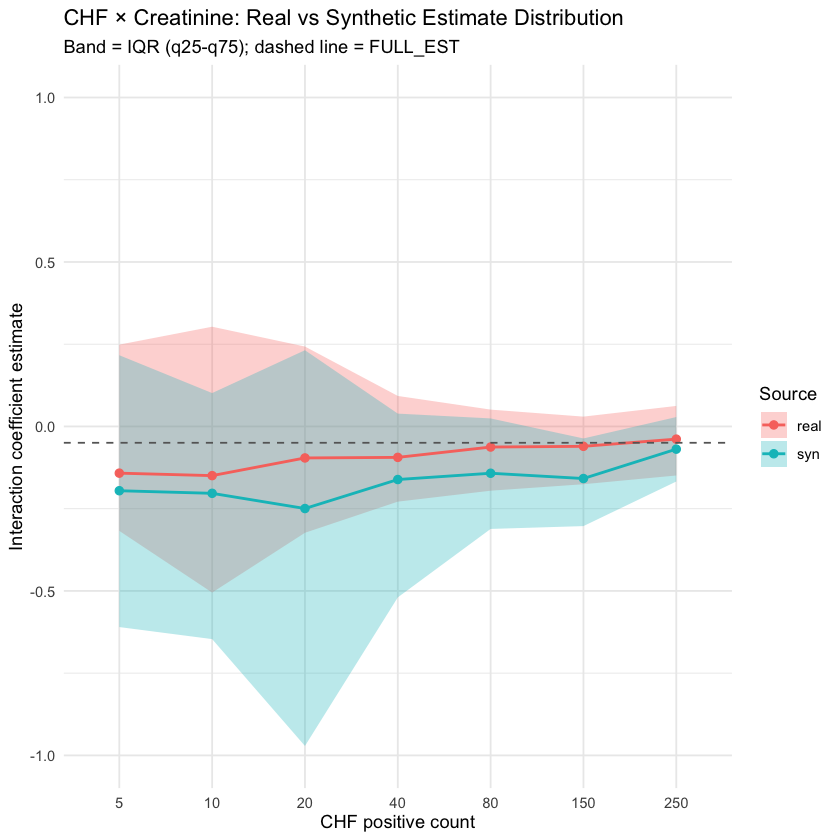

In [27]:
plot_df <- sweep_chf$quantile_summary %>%
  pivot_longer(
    cols = -count,
    names_to = c("source", "quantile"),
    names_pattern = "(real|syn)_q(\\d+)",
    values_to = "value"
  ) %>%
  mutate(quantile = paste0("q", quantile)) %>%
  pivot_wider(names_from = quantile, values_from = value)

ggplot(plot_df, aes(x = factor(count), color = source, fill = source)) +
  geom_ribbon(aes(ymin = q25, ymax = q75, group = source), alpha = 0.3, color = NA) +
  geom_line(aes(y = q50, group = source), linewidth = 0.8) +
  geom_point(aes(y = q50), size = 2) +
  geom_hline(yintercept = FULL_EST_chf, linetype = "dashed", color = "grey40") +
  coord_cartesian(ylim = c(-1, 1)) +
  labs(title = "CHF × Creatinine: Real vs Synthetic Estimate Distribution",
       subtitle = "Band = IQR (q25-q75); dashed line = FULL_EST",
       x = "CHF positive count", y = "Interaction coefficient estimate",
       color = "Source", fill = "Source") +
  theme_minimal()

## Generalization Check: Diabetes × Creatinine

In [32]:
FULL_EST_diabetes <- get_full_est("diabetes", pool)
print(FULL_EST_diabetes)

creatinine_max_capped:diabetes 
                    -0.0709239 


In [16]:
sweep_diabetes <- run_comorbidity_sweep("diabetes", pool, counts, n_fixed, M)
print(sweep_diabetes$quantile_summary, width = Inf)

# A tibble: 7 × 11
  count real_q10 real_q25 real_q50 real_q75 real_q90 syn_q10 syn_q25 syn_q50
  <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>   <dbl>   <dbl>   <dbl>
1     5   -0.845   -0.354  -0.222   0.0189    2.20    -1.24   -0.450 -0.212 
2    10   -0.837   -0.372  -0.204  -0.0510    0.811   -3.05   -0.671 -0.179 
3    20   -0.868   -0.309  -0.0820  0.266     0.679   -1.87   -0.438 -0.113 
4    40   -0.597   -0.315  -0.101   0.145     0.490   -0.974  -0.450 -0.149 
5    80   -0.285   -0.151  -0.0447  0.0337    0.111   -0.666  -0.287 -0.110 
6   150   -0.295   -0.209  -0.105  -0.00899   0.0681  -0.452  -0.253 -0.106 
7   250   -0.256   -0.151  -0.0617  0.0197    0.104   -0.285  -0.152 -0.0506
  syn_q75 syn_q90
    <dbl>   <dbl>
1  1.08    26.3  
2  0.186   17.9  
3  0.277    2.87 
4  0.126    0.473
5  0.0658   0.205
6  0.0194   0.115
7  0.0584   0.154


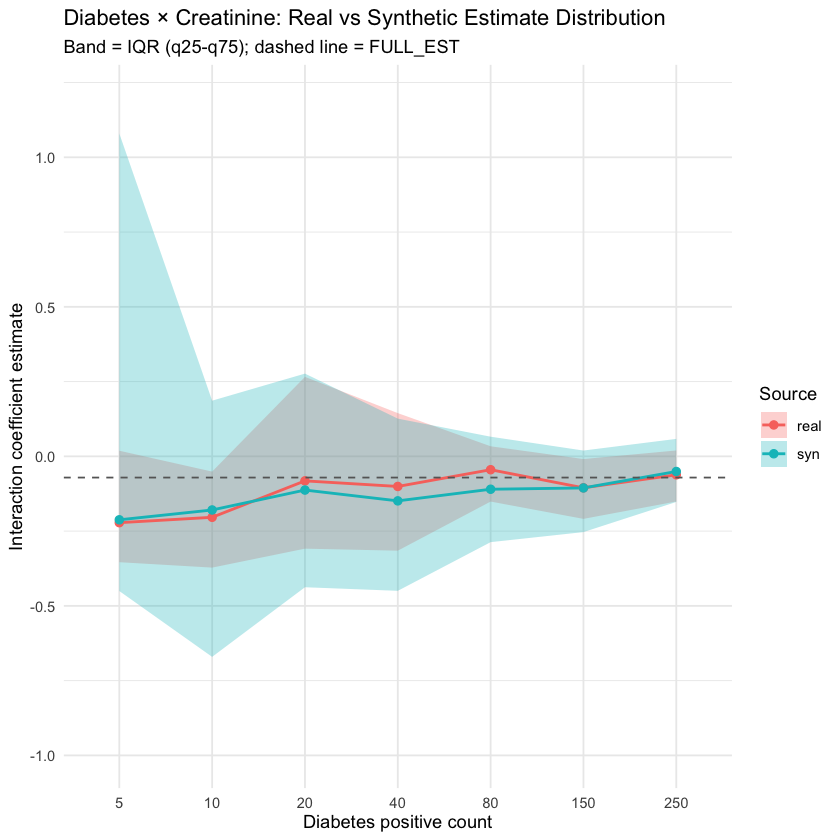

In [38]:
plot_df_dm <- sweep_diabetes$quantile_summary %>%
  pivot_longer(
    cols = -count,
    names_to = c("source", "quantile"),
    names_pattern = "(real|syn)_q(\\d+)",
    values_to = "value"
  ) %>%
  mutate(quantile = paste0("q", quantile)) %>%
  pivot_wider(names_from = quantile, values_from = value)

ggplot(plot_df_dm, aes(x = factor(count), color = source, fill = source)) +
  geom_ribbon(aes(ymin = q25, ymax = q75, group = source), alpha = 0.3, color = NA) +
  geom_line(aes(y = q50, group = source), linewidth = 0.8) +
  geom_point(aes(y = q50), size = 2) +
  geom_hline(yintercept = FULL_EST_diabetes, linetype = "dashed", color = "grey40") +
  coord_cartesian(ylim = c(-1, 1.2)) +
  labs(title = "Diabetes × Creatinine: Real vs Synthetic Estimate Distribution",
       subtitle = "Band = IQR (q25-q75); dashed line = FULL_EST",
       x = "Diabetes positive count", y = "Interaction coefficient estimate",
       color = "Source", fill = "Source") +
  theme_minimal()

## Generalization Check: COPD × Creatinine

In [33]:
FULL_EST_copd     <- get_full_est("copd", pool)
print(FULL_EST_copd)

creatinine_max_capped:copd 
                0.06680412 


In [17]:
sweep_copd <- run_comorbidity_sweep("copd", pool, counts, n_fixed, M)
print(sweep_copd$quantile_summary, width = Inf)

# A tibble: 7 × 11
  count real_q10 real_q25 real_q50 real_q75 real_q90 syn_q10 syn_q25 syn_q50
  <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>   <dbl>   <dbl>   <dbl>
1     5  -1.54    -0.484   -0.185     0.147   19.2    -0.957  -0.387 -0.151 
2    10  -0.741   -0.383   -0.0884    0.951   28.3    -2.69   -0.620 -0.105 
3    20  -1.16    -0.255    0.0424    0.584    1.28   -1.78   -0.684 -0.100 
4    40  -0.307   -0.0903   0.113     0.482    0.682  -0.818  -0.321 -0.0186
5    80  -0.275   -0.0984   0.102     0.301    0.480  -0.373  -0.225 -0.0274
6   150  -0.149   -0.0493   0.0734    0.219    0.384  -0.284  -0.148 -0.0290
7   250  -0.0953  -0.0266   0.0802    0.167    0.245  -0.216  -0.114 -0.0212
  syn_q75 syn_q90
    <dbl>   <dbl>
1  0.147    1.77 
2  0.138    7.74 
3  0.278    1.14 
4  0.265    0.462
5  0.154    0.310
6  0.111    0.252
7  0.0983   0.251


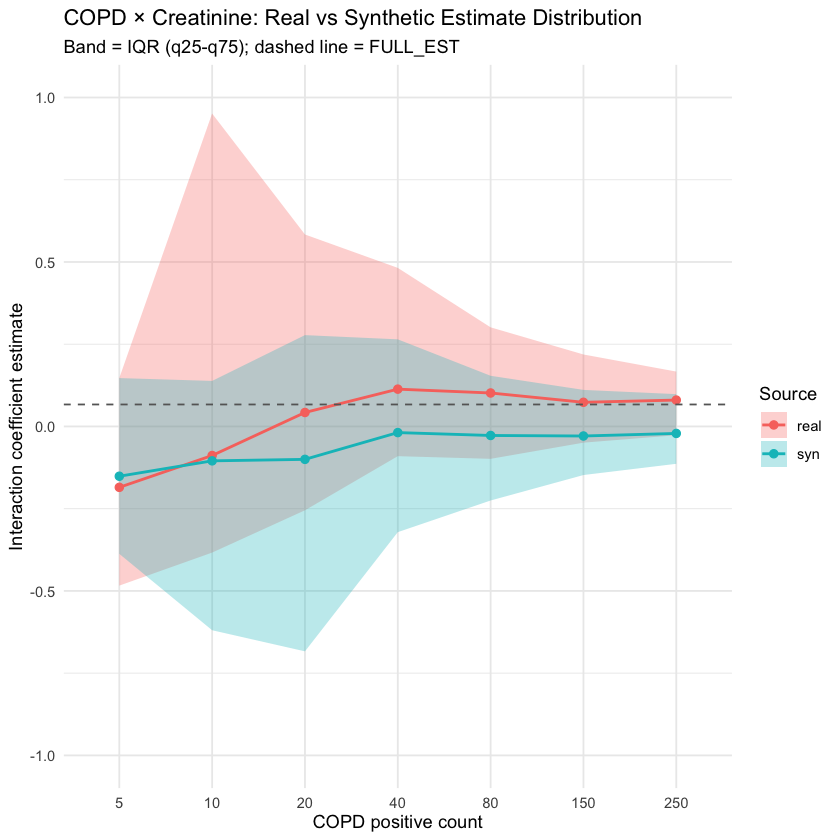

In [35]:
plot_df_copd <- sweep_copd$quantile_summary %>%
  pivot_longer(
    cols = -count,
    names_to = c("source", "quantile"),
    names_pattern = "(real|syn)_q(\\d+)",
    values_to = "value"
  ) %>%
  mutate(quantile = paste0("q", quantile)) %>%
  pivot_wider(names_from = quantile, values_from = value)

ggplot(plot_df_copd, aes(x = factor(count), color = source, fill = source)) +
  geom_ribbon(aes(ymin = q25, ymax = q75, group = source), alpha = 0.3, color = NA) +
  geom_line(aes(y = q50, group = source), linewidth = 0.8) +
  geom_point(aes(y = q50), size = 2) +
  geom_hline(yintercept = FULL_EST_copd, linetype = "dashed", color = "grey40") +
  coord_cartesian(ylim = c(-1, 1)) +
  labs(title = "COPD × Creatinine: Real vs Synthetic Estimate Distribution",
       subtitle = "Band = IQR (q25-q75); dashed line = FULL_EST",
       x = "COPD positive count", y = "Interaction coefficient estimate",
       color = "Source", fill = "Source") +
  theme_minimal()

In [41]:
stability_compare <- bind_rows(
  sweep_chf$quantile_summary      %>% mutate(comorbidity = "CHF"),
  sweep_diabetes$quantile_summary %>% mutate(comorbidity = "Diabetes"),
  sweep_copd$quantile_summary     %>% mutate(comorbidity = "COPD")
) %>%
  mutate(
    real_width = real_q75 - real_q25,
    syn_width  = syn_q75  - syn_q25
  ) %>%
  select(comorbidity, count, real_width, syn_width)

In [40]:
print(stability_compare, n = Inf)

# A tibble: 21 × 4
   comorbidity count real_width syn_width
   <chr>       <dbl>      <dbl>     <dbl>
 1 CHF             5      0.566     0.826
 2 CHF            10      0.808     0.748
 3 CHF            20      0.566     1.20 
 4 CHF            40      0.321     0.559
 5 CHF            80      0.247     0.336
 6 CHF           150      0.206     0.266
 7 CHF           250      0.211     0.196
 8 Diabetes        5      0.373     1.53 
 9 Diabetes       10      0.321     0.857
10 Diabetes       20      0.574     0.714
11 Diabetes       40      0.460     0.576
12 Diabetes       80      0.185     0.353
13 Diabetes      150      0.200     0.273
14 Diabetes      250      0.171     0.211
15 COPD            5      0.631     0.534
16 COPD           10      1.33      0.758
17 COPD           20      0.838     0.961
18 COPD           40      0.572     0.586
19 COPD           80      0.400     0.379
20 COPD          150      0.268     0.259
21 COPD          250      0.193     0.212


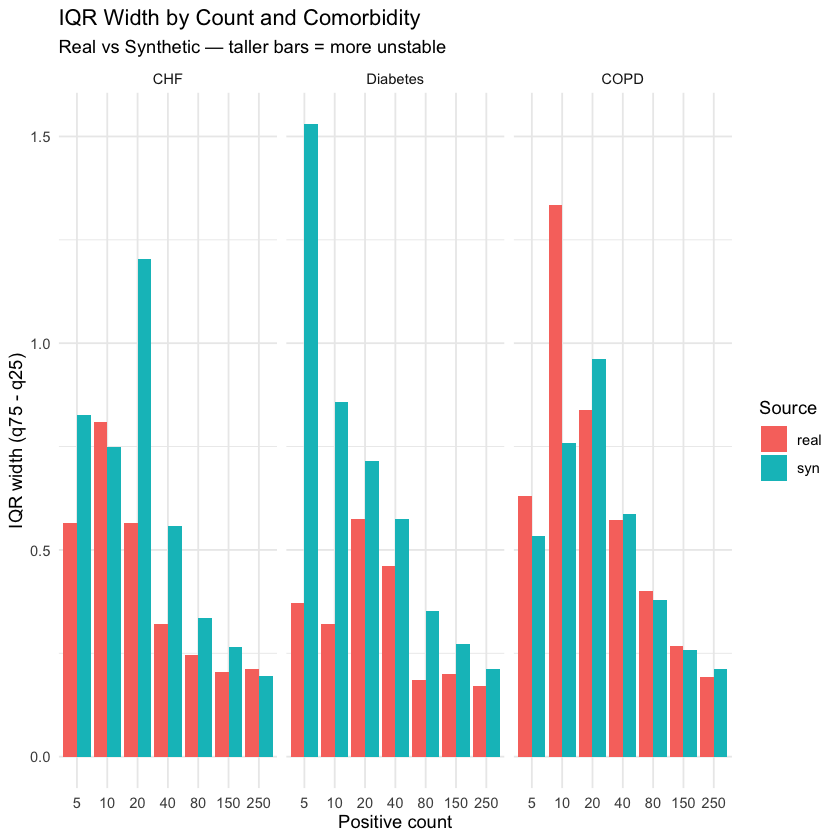

In [43]:
stability_long <- stability_compare %>%
  pivot_longer(cols = c(real_width, syn_width), names_to = "source", values_to = "width") %>%
  mutate(
    source      = ifelse(source == "real_width", "real", "syn"),
    comorbidity = factor(comorbidity, levels = c("CHF", "Diabetes", "COPD"))
  )
ggplot(stability_long, aes(x = factor(count), y = width, fill = source)) +
  geom_col(position = "dodge") +
  facet_wrap(~ comorbidity) +
  labs(title = "IQR Width by Count and Comorbidity",
       subtitle = "Real vs Synthetic — taller bars = more unstable",
       x = "Positive count", y = "IQR width (q75 - q25)",
       fill = "Source") +
  theme_minimal()